In [1]:
from pathlib import Path

import pandas as pd
from tqdm import tqdm

from utils import train_models_for_target

/home/aj/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Configuration

In [2]:
DATA_DIR = Path("output")
CSV_PATTERN = "dataset_winsize*.csv"

OUTPUT_DIR = Path("model_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

TARGETS = {
    "label_time_to_event_seconds": "regression",
    "label_from_zone": "classification",
    "label_to_zone": "classification",
}

DROP_COLUMNS = [
    "fold_id",
    "label_is_auto",
    "label_time_to_event_seconds",
    "label_from_zone",
    "label_to_zone",
]

SUMMARY_FILENAME = "all_metrics_summary.csv"

MODEL_LABELS = {"tree": "Tree", "rf": "Random Forest"}

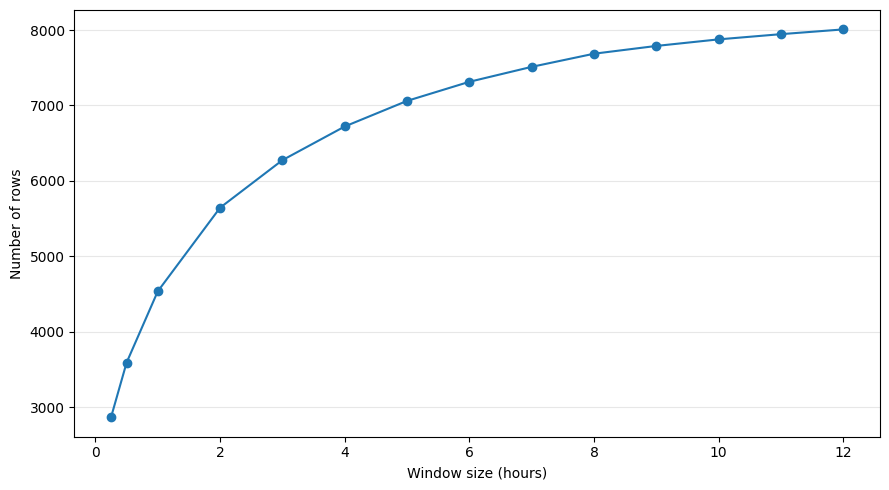

,dataset,winsize,winsize_hours,num_rows
0,dataset_winsize0.25h,0.25,0.25,2869
1,dataset_winsize0.5h,0.5,0.50,3594
2,dataset_winsize01h,01,1.00,4538
3,dataset_winsize02h,02,2.00,5646
4,dataset_winsize03h,03,3.00,6276
5,dataset_winsize04h,04,4.00,6722
6,dataset_winsize05h,05,5.00,7061
7,dataset_winsize06h,06,6.00,7314
8,dataset_winsize07h,07,7.00,7512
9,dataset_winsize08h,08,8.00,7686


In [3]:
import matplotlib.pyplot as plt

row_counts = []

for csv_path in sorted(DATA_DIR.glob(CSV_PATTERN)):
    df = pd.read_csv(csv_path)
    winsize = csv_path.stem.split("winsize", 1)[1].removesuffix("h")
    row_counts.append(
        {
            "dataset": csv_path.stem,
            "winsize": winsize,
            "winsize_hours": float(winsize),
            "num_rows": len(df),
        }
    )

row_counts_df = pd.DataFrame(row_counts).sort_values("winsize_hours")

ax = row_counts_df.plot(
    x="winsize_hours",
    y="num_rows",
    kind="line",
    marker="o",
    figsize=(9, 5),
    legend=False,
)
ax.set_xlabel("Window size (hours)")
ax.set_ylabel("Number of rows")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

row_counts_df

In [4]:
############
# RUN ONCE #
############
# Main loop over datasets (takes abut 30 minutes)

# all_results = []

# csv_files = sorted(DATA_DIR.glob(CSV_PATTERN))

# if len(csv_files) == 0:
#     raise FileNotFoundError(
#         f"No files found matching {CSV_PATTERN} in {DATA_DIR.resolve()}"
#     )

# for csv_path in tqdm(csv_files):
#     dataset_name = csv_path.stem
#     print(f"\nReading {csv_path}")

#     df = pd.read_csv(csv_path)

#     for target_col, task_type in TARGETS.items():

#         metrics_df = train_models_for_target(
#             df=df,
#             dataset_name=dataset_name,
#             target_col=target_col,
#             task_type=task_type,
#             output_dir=OUTPUT_DIR,
#             random_state=RANDOM_STATE,
#             drop_columns=DROP_COLUMNS,
#         )

#         all_results.append(metrics_df)

# final_results = pd.concat(all_results, ignore_index=True)
# final_results.to_csv(OUTPUT_DIR / "all_metrics_summary.csv", index=False)

# print("\nFinal summary:")
# print(final_results)

In [5]:
metrics_df = pd.read_csv(OUTPUT_DIR / SUMMARY_FILENAME)
metrics_df.head()

,mae,median_absolute_error,mse,rmse,r2,dataset,target,task,model,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,157.196390,78.697248,48993.134294,221.343928,0.119525,dataset_winsize0.25h,label_time_to_event_seconds,regression,tree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,150.967884,93.647092,45346.774349,212.947821,0.185055,dataset_winsize0.25h,label_time_to_event_seconds,regression,rf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,dataset_winsize0.25h,label_from_zone,classification,tree,0.355401,0.161944,0.174300,0.148449,0.136624,0.501387,0.355401,0.383028
3,NaN,NaN,NaN,NaN,NaN,dataset_winsize0.25h,label_from_zone,classification,rf,0.536585,0.345244,0.299276,0.316474,0.290139,0.638963,0.536585,0.575050
4,NaN,NaN,NaN,NaN,NaN,dataset_winsize0.25h,label_to_zone,classification,tree,0.296167,0.153683,0.142584,0.140876,0.110448,0.463255,0.296167,0.345962


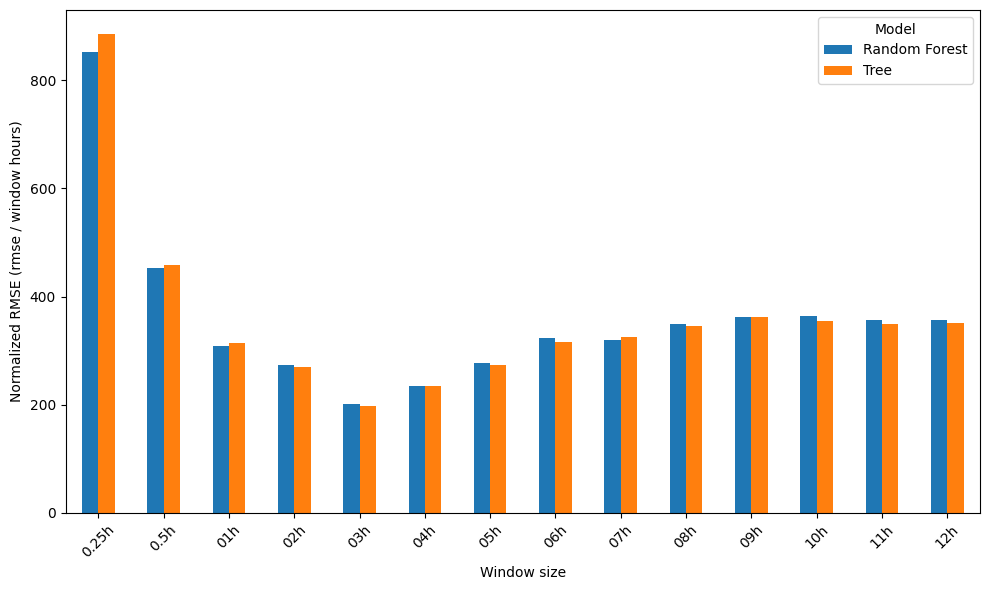

In [6]:
import matplotlib.pyplot as plt

reg_df = metrics_df[
    (metrics_df["task"] == "regression") & (metrics_df["model"].isin(["tree", "rf"]))
].copy()

reg_df["winsize"] = reg_df["dataset"].str.extract(r"winsize(.+)$", expand=False)
reg_df["winsize_hours"] = (
    reg_df["winsize"].str.replace("h", "", regex=False).astype(float)
)
reg_df["rmse_norm"] = reg_df["rmse"] / reg_df["winsize_hours"]

pivot = (
    reg_df.sort_values("winsize_hours")
    .pivot(
        index="winsize",
        columns="model",
        values="rmse_norm",
    )
    .rename(columns=MODEL_LABELS)
)

ax = pivot.plot(kind="bar", figsize=(10, 6))
ax.set_xlabel("Window size")
ax.set_ylabel("Normalized RMSE (rmse / window hours)")
# ax.set_title("Regression RMSE normalized by window size for tree vs rf")
ax.legend(title="Model")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(DATA_DIR / "regression_rmse_norm_bar.pdf", dpi=300, bbox_inches="tight")
plt.show()

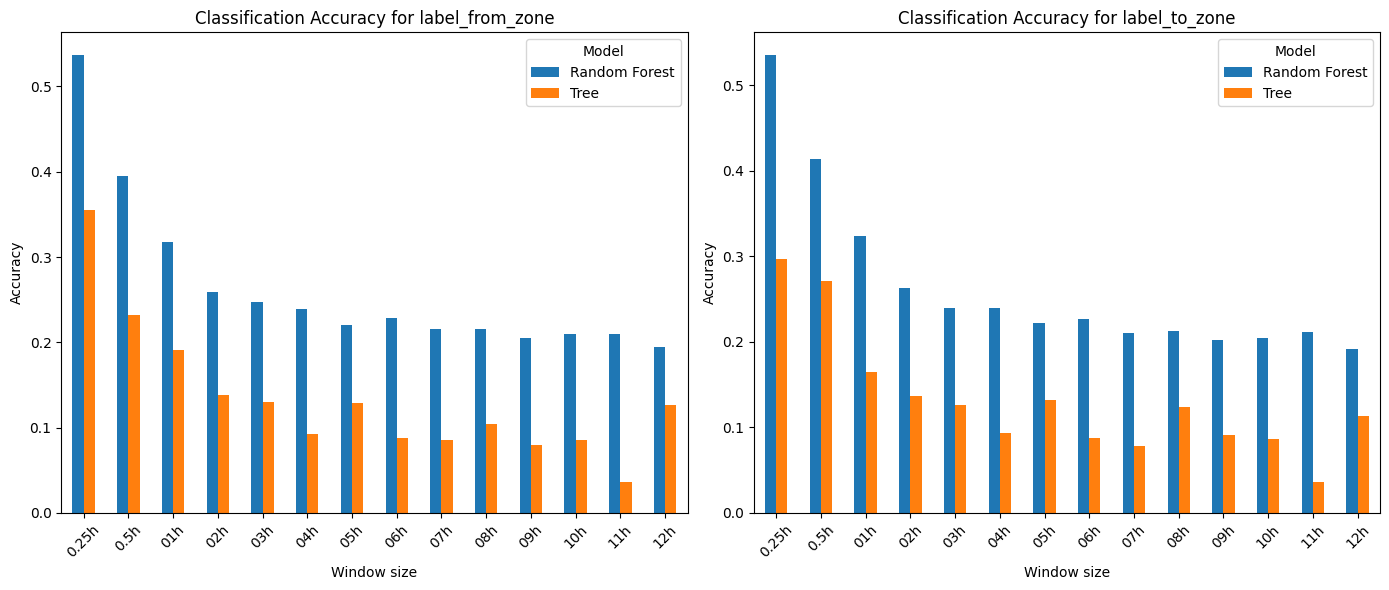

In [7]:
class_df = metrics_df[
    (metrics_df["task"] == "classification")
    & (metrics_df["target"].isin(["label_from_zone", "label_to_zone"]))
    & (metrics_df["model"].isin(["tree", "rf"]))
].copy()

class_df["winsize"] = class_df["dataset"].str.extract(r"winsize(.+)$", expand=False)
class_df["winsize_hours"] = (
    class_df["winsize"].str.replace("h", "", regex=False).astype(float)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, target in enumerate(["label_from_zone", "label_to_zone"]):
    target_data = class_df[class_df["target"] == target].sort_values("winsize_hours")
    pivot = target_data.pivot(
        index="winsize", columns="model", values="accuracy"
    ).rename(columns=MODEL_LABELS)

    ax = pivot.plot(kind="bar", ax=axes[idx])
    ax.set_xlabel("Window size")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"Classification Accuracy for {target}")
    ax.legend(title="Model")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [8]:
# train a classification model for time intervals
# %run train_time_interval_classification.py

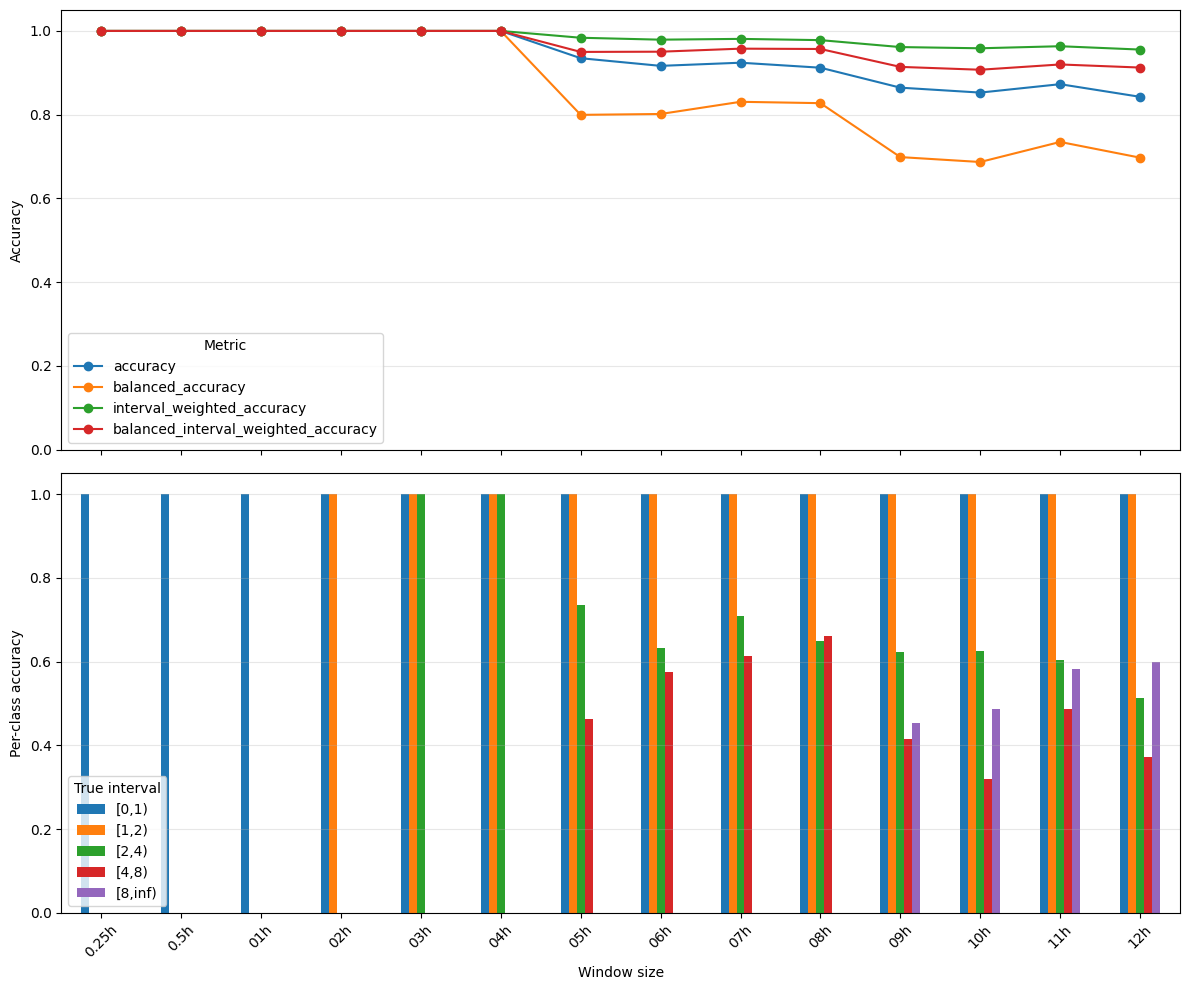

In [9]:
interval_metrics_path = OUTPUT_DIR / "time_interval_rf" / "all_interval_metrics.csv"
interval_df = pd.read_csv(interval_metrics_path)

interval_df["winsize"] = interval_df["dataset"].str.extract(
    r"winsize(.+)$", expand=False
)
interval_df["winsize_hours"] = (
    interval_df["winsize"].str.replace("h", "", regex=False).astype(float)
)
interval_df = interval_df.sort_values("winsize_hours")

metric_cols = [
    "accuracy",
    "balanced_accuracy",
    "interval_weighted_accuracy",
    "balanced_interval_weighted_accuracy",
]
class_accuracy_cols = [c for c in interval_df.columns if c.startswith("accuracy_[")]

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

interval_df.plot(
    x="winsize",
    y=metric_cols,
    marker="o",
    ax=axes[0],
)
axes[0].set_xlabel("")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1.05)
axes[0].legend(title="Metric", loc="lower left")
axes[0].grid(axis="y", alpha=0.3)

class_accuracy = interval_df.set_index("winsize")[class_accuracy_cols]
class_accuracy.columns = [c.removeprefix("accuracy_") for c in class_accuracy.columns]
class_accuracy.plot(kind="bar", ax=axes[1])
axes[1].set_xlabel("Window size")
axes[1].set_ylabel("Per-class accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].legend(title="True interval", loc="lower left")
axes[1].grid(axis="y", alpha=0.3)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()